# Experimentation with the readings of the signal code

In [11]:

import os
import numpy as np
from matplotlib import pyplot as plt

def read_multichannel_bin_data(filepath, quantum=0.0050863, skip_s=0, length_s=0):
    # filepath : path to the .bin file
    # quantum  : acquisition quantum -- scaling factor that converts the raw binary values (signed 16-bit integers, >i2) into physical units (likely volts or microvolts).
        #The file contains 2-byte signed integers representing the raw ADC (Analog-to-Digital Converter) counts from the acquisition hardware.

    # skip_s   : Time (in seconds) to skip (ie. ignore) at the beginning of the file
    # length_s : Time (in seconds) of data to read (leave 0 to read whole file)
    
    Fs               = 10000 # Hz
    N_channels       = 64 # Channnels -- electrodes, each channel is an electrode in the MEA
    data_width_bytes = 2  # 2 bytes per sample (>i2 : signed 2-byte integers, big-endian)
    filesize = os.path.getsize(filepath)
    
    # At every sampling time (1/Fs), 64 samples (1 for every channel) are recorded
    # They are recorded in a 128B chunk (2B per channel)
    #   @0x0000 <Sample0/Ch0><Sample0/Ch1><Sample0/Ch2> ... <Sample0/Ch63> (@t=0 s)
    #   @0x0080 <Sample1/Ch0><Sample1/Ch1><Sample1/Ch2> ... <Sample1/Ch63> (@t=0.1 ms)
    #   @0x0100 <Sample2/Ch0><Sample2/Ch1><Sample2/Ch2> ... <Sample2/Ch63> (@t=0.2 ms)
    #                                                   ...
    #   @0x---- <SampleN/Ch0><SampleN/Ch1><SampleN/Ch2> ... <SampleN/Ch63> (@t=N*0.1e-3 s)

    ''' Number of chunks in requested data '''
    skip_chunks   = int(skip_s   * Fs) # Number of 128b chunks to skip - converts seconds to number of samples/time points
    length_chunks = int(length_s * Fs) # Number of 128b chunks to read - converts seconds to number of samples/time points
    
    """Each chunk = one time point × 64 channels × 2 bytes = 128 bytes
        So:
            skip_bytes = 20,000 × 128 = 2,560,000 bytes

            length_bytes = 30,000 × 128 = 3,840,000 bytes"""
    
    
    ''' Handle cases where skip_s is unspecified(0) and/or length_s is unspecified (0) '''
    if (length_chunks == 0) and (skip_chunks == 0):
        # If no length or skip specified, read the whole file
        length_chunks = int(filesize / (N_channels * data_width_bytes))
        
    if (length_chunks == 0) and (skip_chunks > 0):
        # If no length specified but non-zero skip, read until end of file
        length_chunks = int(filesize / (N_channels * data_width_bytes) - skip_chunks)
    
    ''' Number of bytes in requested data '''
    skip_bytes   = int(skip_chunks   * N_channels * data_width_bytes)
    length_bytes = int(length_chunks * N_channels * data_width_bytes)
    
    print(f"Reading {length_bytes}B from offset {skip_bytes} (0x{skip_bytes:X})")
    
    ''' Read file'''
    with open(filepath, 'rb') as fid:
        if skip_bytes > 0:
            fid.seek(skip_bytes)
        data = np.fromfile(fid, dtype='>i2', count=length_bytes // data_width_bytes)
    print("20 first points of data (binary values) : ")
    for x in data[:20]:
        print(x, end=',')
    print()
    
    data = data.reshape(length_chunks, N_channels)
    print("All done.")
    
    return data * quantum


## Example 1 : chargement du début de fichier, seulement 10s 





In [14]:
filepath = r"Data\Donnes\donnees\20180116-MEAPedot8-P1107-MERGE.bin"
skip_s   = 0
length_s = 10

Fs = 10000
data = read_multichannel_bin_data(filepath, length_s=length_s, skip_s=skip_s)

L = data.shape[0] # Data length (samples)
N = data.shape[1] # Number of channels

time = np.linspace(start=skip_s, stop=skip_s + L/Fs, num=L, endpoint=False)

Reading 12800000B from offset 0 (0x0)
20 first points of data (binary values) : 
0,-384,-335,-1013,-870,-750,-281,0,-1593,71,-277,-705,-536,-1290,245,-170,-1165,-1174,-1209,-1165,
All done.


Data shape : (100000, 64)
[[ 0.        -1.9531392 -1.7039105 ...  2.3142665 -0.6815642  0.       ]
 [ 0.        -5.493204   1.0223463 ...  7.0394392 -5.8543313  0.       ]
 [ 0.        -8.036354  -8.4229128 ...  0.864671  -8.2194608  0.       ]
 ...
 [ 0.        -5.9458847 -6.3324435 ... -6.2205449 -0.864671   0.       ]
 [ 0.        -5.0405233  2.1108145 ... -1.4089051 -0.1373301  0.       ]
 [ 0.        -5.8543313 -0.5238889 ...  0.406904  -4.1300756  0.       ]]
Time shape : (100000,)
[0.0000e+00 1.0000e-04 2.0000e-04 ... 9.9997e+00 9.9998e+00 9.9999e+00]


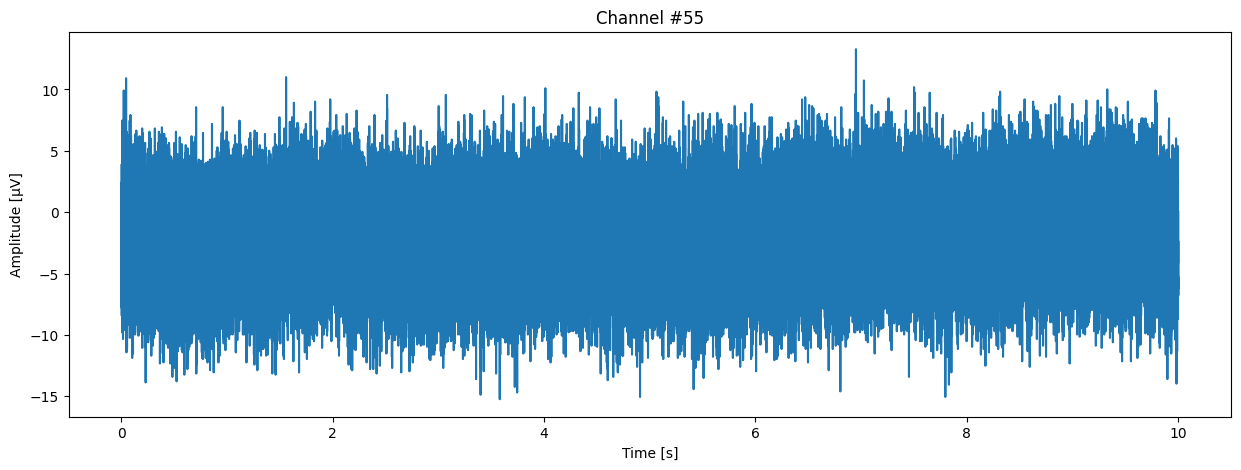

'E = 15 # Channel of interest (idx 15 <=> electrode 28)\nplt.figure(figsize=(15,5))\nplt.plot(time, data[:,E])\nplt.xlabel("Time [s]")\nplt.ylabel("Amplitude [µV]")\nplt.title(f"Channel #{E}")\nplt.plot()\nplt.show()'

In [15]:
print(f"Data shape : {data.shape}")
print(data)
print(f"Time shape : {time.shape}")
print(time)

E = 55 # Channel of interest (idx 20 <=> electrode 35)
plt.figure(figsize=(15,5))
plt.plot(time, data[:,E])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [µV]")
plt.title(f"Channel #{E}")
plt.plot()
plt.show()

"""E = 48 # Channel of interest (idx 48 <=> electrode 71)
plt.figure(figsize=(15,5))
plt.plot(time, data[:,E])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [µV]")
plt.title(f"Channel #{E}")
plt.plot()
plt.show()"""

"""E = 15 # Channel of interest (idx 15 <=> electrode 28)
plt.figure(figsize=(15,5))
plt.plot(time, data[:,E])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [µV]")
plt.title(f"Channel #{E}")
plt.plot()
plt.show()"""


## Informations sur le fichier 

In [16]:
def read_multichannel_bin_info(filepath):
    Fs               = 10000 # Hz
    N_channels       = 64 # Channnels
    data_width_bytes = 2  # 2 bytes per sample (>i2 : signed 2-byte integers, big-endian)
    filesize = os.path.getsize(filepath)
    
    # At every sampling time (1/Fs), 64 samples (1 for every channel) are recorded
    # They are recorded in a 128B chunk (2B per channel)
    #   @0x0000 <Sample0/Ch0><Sample0/Ch1><Sample0/Ch2> ... <Sample0/Ch63> (@t=0 s)
    #   @0x0080 <Sample1/Ch0><Sample1/Ch1><Sample1/Ch2> ... <Sample1/Ch63> (@t=0.1 ms)
    #   @0x0100 <Sample2/Ch0><Sample2/Ch1><Sample2/Ch2> ... <Sample2/Ch63> (@t=0.2 ms)
    #                                                   ...
    #   @0x---- <SampleN/Ch0><SampleN/Ch1><SampleN/Ch2> ... <SampleN/Ch63> (@t=N*0.1e-3 s)

    length_chunks = int(filesize / (N_channels * data_width_bytes))
    length_bytes = int(length_chunks * N_channels * data_width_bytes)
    length_samples = length_bytes // data_width_bytes
    
    length_s = length_samples
    bitrate_Bps = N_channels * data_width_bytes * Fs
    
    print(f"File is {length_bytes} bytes long.")
    print(f"Bitrate is {bitrate_Bps} B/s")
    print(f"File is {length_bytes / bitrate_Bps} s long.")
    print(f"Expected data size is {length_chunks}x{N_channels}")
    
read_multichannel_bin_info(filepath)

File is 7293312000 bytes long.
Bitrate is 1280000 B/s
File is 5697.9 s long.
Expected data size is 56979000x64
